In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Ellipse
import os

from scipy.stats import norm

import xgboost as xgb

from sklearn.covariance import MinCovDet, EmpiricalCovariance
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC # --> SVC: classification class of SVM (State Vector Machine)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split



from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_experiments.library import StateTomography
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer.noise import NoiseModel, ReadoutError


data = np.load(os.getcwd()+'/files/datafiles/x.npz')
X00, X11, X01, X10 = data['X00'], data['X11'], data['X01'], data['X10']

X = np.vstack([X00, X01, X10, X11])

y = np.concatenate([
    np.zeros(len(X00)),
    np.ones(len(X01)),
    np.full(len(X10), 2),
    np.full(len(X11), 3)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
props = backend.properties()

qiskit_runtime_service.__init__:WARNING:2026-05-28 09:11:15,851: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-28 09:11:15,853: Using instance: open-instance, plan: open


# Readout Errors
To understand the readout error and to design an algorithm to mitigate it, the raw data should be extracted from the backend. Usually, quantum computing backends (including IBM) readout data are in binary system ("0" or "1"). However, under the hood, the quantum computer is actually bouncing a microwave pulse off the qubit and measuring its electrical signal. The raw signal readout voltages has an I (In-phase) and a Q (Quadrature) components that creates a coordinate on a 2D map, where the states of the qubit and its error is derived based on the I&Q data map after measuring them for several thousands shots.

The readout error is defined as:

$P_{readout-error}$ = P_read0_given1 + P_read1_given0

### Data Extraction
To extract the I&Q components (the raw readout voltages) from the IBM backend, the `StateTomography` class of the `qiskit_experiments` library was used. The following snippet shows the steps to extract IQ data for a single qubit after creating a basic circuit:

In [ ]:
# connecting to ibm
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

# creating the basic circuit
qc = QuantumCircuit(1)
qc.measure_all()

# reconstructing quantum state and measuring in Z, X, Y basis 
exp = StateTomography(qc)

# transpiler is the qiskit translator
exp.set_transpile_options(translation_method='translator',optimization_level=1 )
exp.set_run_options(meas_level=1, meas_return='single') # meas_level=1 --> asking for IQ voltage data

# run the experiment by sendig the job to ibm cloud --> most time consuming part
job = exp.run(backend,qubits=[nq],shots=150000) # --> shots = 15000 for this study to have enough data for ML algos; nq is the qubit ID
job.block_for_results()
iq = job.data()[0]['memory']
I,Q = iq[:, 0, 0], iq[:, 0, 1]

### IQ data for double-qubits

To include the crosstalk effects among neighboring qubits, and to include more comprehensive quantum states ($\ket{0}, \ket{1}$) multiple neighboring qubits should be selected among the backend qubits. As the computational power is limited the number of qubits are limited to two qubits. An educated guess is to select a qubit and find the neighbor with highest readout error and run the `StateTomography` for both of them. To use IQ data for Machine Learning algorithms, `nshot=15000`. The data are prepared in four states: $\ket{00}, \ket{01}, \ket{10}, \ket{11}$ where the indices are: $\ket{n1}\ket{n2}$

In [ ]:


service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
props = backend.properties()
nq1 = 127
coupling_map = backend.coupling_map
connections = coupling_map.get_edges()
neighbors = coupling_map.neighbors(nq1)
rerrors = [np.round(props.readout_error(i),3).item() for i in list(neighbors)]
nq2 = [i for i in list(neighbors) if np.round(props.readout_error(i),3).item() == max(rerrors)][0]
print(f'2nd qubit index: {nq2}, readout-error={rerrors}, all neighbors:', neighbors)

def job_state(nq1,nq2,i,j):
    qc = QuantumCircuit(2)
    if i > 0: qc.x(0)
    if j > 0: qc.x(1)
    qc.measure_all()
    exp = StateTomography(qc)
    exp.set_transpile_options(translation_method='translator',optimization_level=1 )
    exp.set_run_options(meas_level=1, meas_return='single')
    job = exp.run(backend,qubits=[nq1,nq2],shots=15000)
    job.block_for_results()

    iq1, iq2 = job.data()[0]['memory'], job.data()[0]['memory']
    I1,Q1 = iq1[:, 0, 0], iq1[:, 0, 1]
    I2,Q2 = iq2[:, 1, 0], iq2[:, 1, 1]
    return I1,Q1, I2,Q2

# assuming nq2 = 128:
I1_00, Q1_00, I2_00, Q2_00 = job_state(127, 128, 0, 0) # both qubits in state |0>
I1_11, Q1_11, I2_11, Q2_11 = job_state(127, 128, 1, 1) # both qubits in state |1>
I1_01, Q1_01, I2_01, Q2_01 = job_state(127, 128, 0, 1) # 127: |0>, 128: |1>
I1_10, Q1_10, I2_10, Q2_10 = job_state(127, 128, 1, 0) # 127: |1>, 128: |0>

X00 = np.column_stack([I1_00, Q1_00, I2_00, Q2_00])  # shape (shots_00, 4)
X01 = np.column_stack([I1_01, Q1_01, I2_01, Q2_01])  # shape (shots_01, 4)
X10 = np.column_stack([I1_10, Q1_10, I2_10, Q2_10])  # shape (shots_10, 4)
X11 = np.column_stack([I1_11, Q1_11, I2_11, Q2_11])  # shape (shots_11, 4)

# Save data as npz file as this process will exhaust the ibm queue
np.savez(os.getcwd()+'/../files/datafiles/x.npz', X00=X00, X01=X01, X10=X10, X11=X11)


qiskit_runtime_service.__init__:WARNING:2026-05-18 11:54:18,284: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-18 11:54:18,285: Using instance: open-instance, plan: open


2nd qubit index: 126, readout-error=[0.151, 0.007, 0.035], all neighbors: NodeIndices[126, 137, 128]


### Visualize IQ Data
Plotting IQ data for individual qubits and various states shows how separable the IQ plots are for different states, and how the readout error could be mitigated by separating them. In addition, IQ plots for multiple qubits shows the crosstalk effect of neighboring qubits.

These scenarios are plotted followingly:

1. The effect of neighboring ground states on the qubit excited state: $\ket{00}$ and $\ket{01}$ for qubit=127 and $\ket{00}$ and $\ket{10}$ for qubit=128
2. The effect of neighboring excited states on the excited state: $\ket{11}$ and $\ket{01}$ for qubit=127 and $\ket{11}$ and $\ket{10}$ for qubit=128

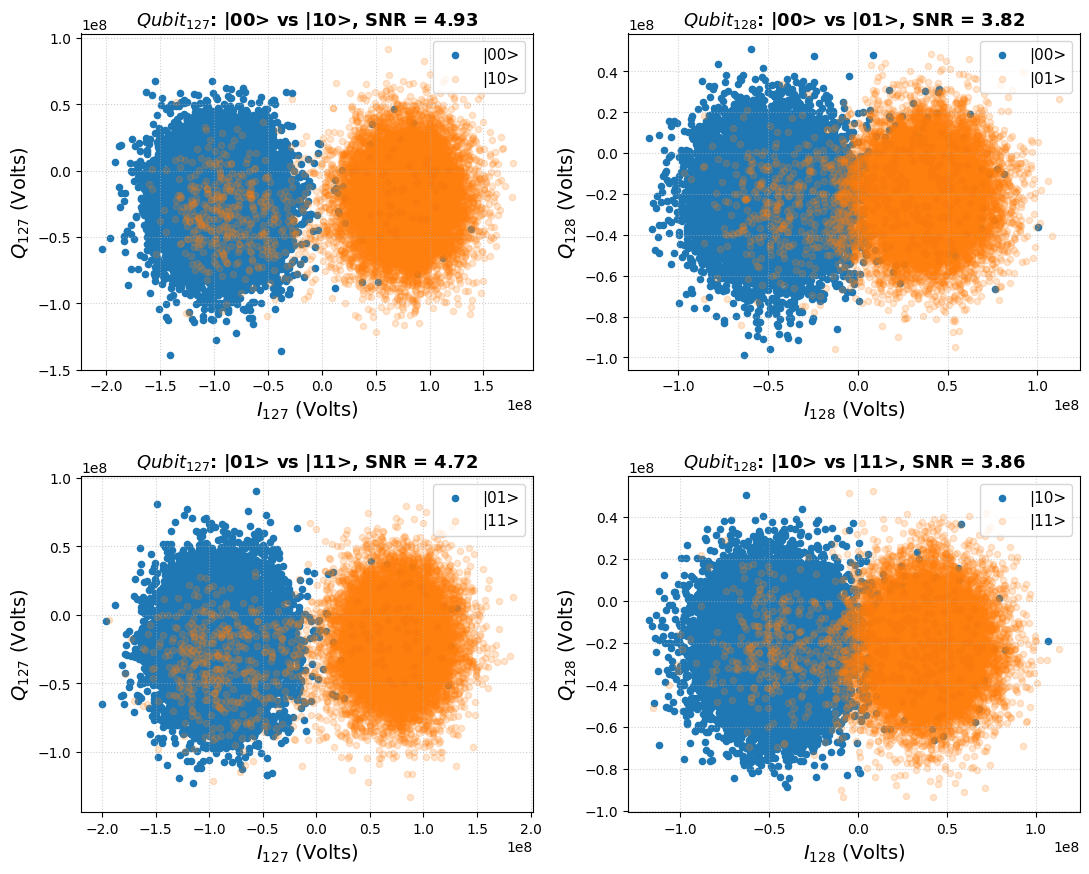

In [ ]:
grid_config = [
    (0, 0, 127, 0, 1, X00, '|00>', X10, '|10>', 0.2), 
    (0, 1, 128, 2, 3, X00, '|00>', X01, '|01>', 0.2),
    (1, 0, 127, 0, 1, X01, '|01>', X11, '|11>', 0.2),
    (1, 1, 128, 2, 3, X10, '|10>', X11, '|11>', 0.2)
]

def snr_double_qubits(X_prim, X_sec, nq):
    if nq == 1:
        cluster0 = X_prim[:, :2]
        cluster1 = X_sec[:, :2]
    else:
        cluster0 = X_prim[:, 2:]
        cluster1 = X_sec[:, 2:]

    mu0 = np.mean(cluster0, axis=0)
    mu1 = np.mean(cluster1, axis=0)

    center_distance = np.linalg.norm(mu1 - mu0)
    direction_vector = (mu1 - mu0) / center_distance
    cov0 = np.cov(cluster0, rowvar=False)
    cov1 = np.cov(cluster1, rowvar=False)

    var0_projected = direction_vector.T @ cov0 @ direction_vector
    var1_projected = direction_vector.T @ cov1 @ direction_vector

    sigma0 = np.sqrt(var0_projected)
    sigma1 = np.sqrt(var1_projected)

    average_noise = 0.5 * (sigma0 + sigma1)
    snr = center_distance / average_noise
    return snr

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for row, col, i, i_col, q_col, X_prim, lbl_prim, X_sec, lbl_sec, a_sec in grid_config:
    if i == 127: snr = snr_double_qubits(X_prim, X_sec, 1)
    else: snr = snr_double_qubits(X_prim, X_sec, 2)
    ax = axes[row, col]
    ax.scatter(X_prim[:, i_col], X_prim[:, q_col], s=20, alpha=1.0, label=lbl_prim)
    ax.scatter(X_sec[:, i_col], X_sec[:, q_col], s=20, alpha=a_sec, label=lbl_sec)
    ax.set_xlabel(fr"$I_{{{i}}}$ (Volts)", fontsize=14)
    ax.set_ylabel(fr"$Q_{{{i}}}$ (Volts)", fontsize=14)
    ax.set_title(fr'$Qubit_{{{i}}}$: {lbl_prim} vs {lbl_sec}, SNR = {snr:.2f}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

From this plot it is shown that qubit 128 has a higher readout error. This could also be shown by:

In [52]:
# N.B.: the downloaded X arrays where not synched with the following errors!!!
q128_rerr = props.readout_error(128)
q127_rerr = props.readout_error(127)
print(f'readout error for qubit = 128:   {q128_rerr*100:.3f}%,   qubit = 127:  {q127_rerr*100:.3f} %')

readout error for qubit = 128:   3.503%,   qubit = 127:  8.142 %


### IQ Map Geometrical Parameters
To identify what are the tilting angle of the 2D distribution of IQ map and how well the distribution is circular, the two parameters below are used:

$$\theta = 0.5 \times arctan{\frac{\sigma_{IQ}}{\sigma_{II}-\sigma_{QQ}}}$$
$$\rho = \frac{\sigma_{IQ}}{\sqrt{\sigma_{II}\times\sigma_{QQ}}}$$

The amount the distribution is tilted w.r.t. the horizontal axis is assessed with $\theta$ (measured in degrees): low values small tilting and high values large tilting;

The amount the distribution is symmetric (or circular) in IQ plane is evaluated with $\rho$ values: small $\rho$ IQ mapping is circular, large $\rho$ IQ mapping is elliptical


In [ ]:
def compute_geom(data, state):
    cov = np.cov(data.T)
    theta = 0.5 * np.arctan2(2 * cov[0,1], cov[0,0] - cov[1,1])
    rho = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    print(f'  |{state}>  theta = {np.degrees(theta):.2f} degree,     rho = {rho:.2e} ')
    return theta, rho

state = {0 : '00', 1 : '01', 2 : '10', 3 : '11'}

for q in (127, 128):
    print(f'qubit: {q}')
    for n,x in enumerate([X00, X01, X10, X11]):
        compute_geom(x[:,:2], state[n]) if q == 127 else compute_geom(x[:,2:], state[n])

qubit: 127
  |00>  theta = -0.73 degree,     rho = -2.20e-03 
  |01>  theta = 5.33 degree,     rho = 1.46e-02 
  |10>  theta = 5.55 degree,     rho = 6.44e-02 
  |11>  theta = 6.58 degree,     rho = 7.96e-02 
qubit: 128
  |00>  theta = 2.74 degree,     rho = 1.19e-02 
  |01>  theta = 5.18 degree,     rho = 3.14e-02 
  |10>  theta = -0.06 degree,     rho = -2.66e-04 
  |11>  theta = 0.69 degree,     rho = 4.09e-03 


### Distance from IQ blob
Used Mahalanobis distance instead of Eucleadian distance to account for the IQ-plane diagonal variance. To see the effect of the Modified Minimum covariant the empirical covariance and the minimum covariance methods are used. For the purpose of demonstration MCD and original Mahalanobis distances are used on the entire datasets.

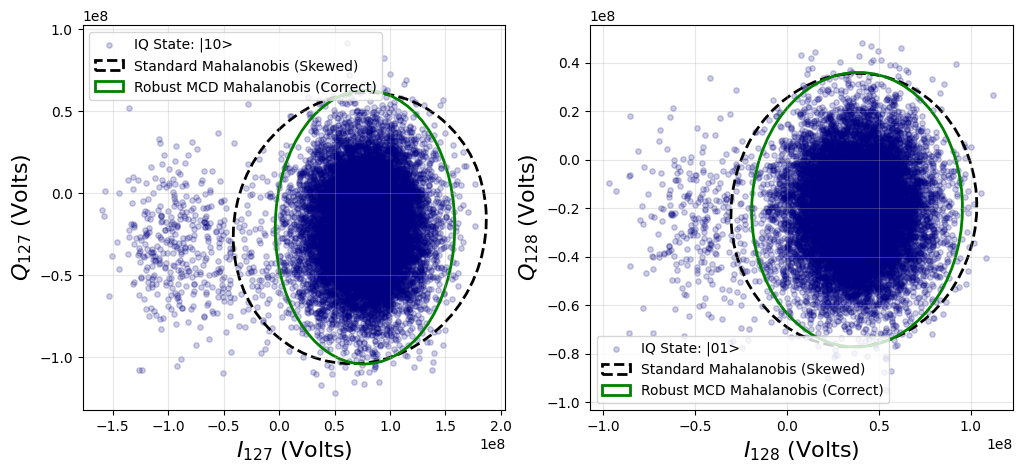

In [ ]:


def draw_ellipse(mcd, ax, color, label, linestyle='-'):
    """Draws a 3-sigma Mahalanobis contour."""
    cov = mcd.covariance_
    center = mcd.location_
        
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
        
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))        
    width, height = 2 * 3 * np.sqrt(vals)
        
    ell = Ellipse(xy=center, width=width, height=height, angle=theta,
                      edgecolor=color, facecolor='none', lw=2, 
                      linestyle=linestyle, label=label)
    ax.add_patch(ell)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,nqu in enumerate([127, 128]):
    if nqu == 127:
        ax[i].scatter(X10[:,0], X10[:,1], color='navy', alpha=0.2, s=15, label=f'IQ State: |10>')
        standard_cov = EmpiricalCovariance().fit(X10[:,:2])
        robust_cov = MinCovDet().fit(X10[:,:2]) 
    else:
        ax[i].scatter(X01[:,2], X01[:,3], color='navy', alpha=0.2, s=15, label=f'IQ State: |01>')
        standard_cov = EmpiricalCovariance().fit(X01[:,2:])
        robust_cov = MinCovDet().fit(X01[:,2:])
    draw_ellipse(standard_cov, ax[i], 'black', 'Standard Mahalanobis (Skewed)', '--')
    draw_ellipse(robust_cov, ax[i], 'green', 'Robust MCD Mahalanobis (Correct)')
    ax[i].set_xlabel(fr"$I_{{{nqu}}}$ (Volts)", fontsize=16)
    ax[i].set_ylabel(fr"$Q_{{{nqu}}}$ (Volts)", fontsize=16)
    ax[i].legend()
    ax[i].grid(True, alpha=0.3)

plt.savefig(os.getcwd()+'/files/plots/maha_qu1-10_qu2-01.png')

### Quantum States IQ Separation
1. Mahalanobis distance: Useful to eliminate outliers;
2. Gaussian Mixture Models: Takes all the combinations of double-qubits' states as input;
3. SVC Models: State Vector Classification model 
4. LR Model: Benchmark to evaluate other models

Used 80% of data to train and 20% for test with the same random state for the purpose of valid comparison among runs

### Check Mahalanobis corrected Version

In [3]:
def train_mcd_discriminator_multi(X_list):
    params = []
    for X in X_list:
        mcd = MinCovDet().fit(X)
        mu = mcd.location_
        inv_cov = np.linalg.inv(mcd.covariance_)
        params.append((mu, inv_cov))    
    return params

def predict_mcd_multi(X_test, all_params):
    distances = []
    for mu, inv_cov in all_params:
        diff = X_test - mu
        dist = np.sqrt(np.sum(np.dot(diff, inv_cov) * diff, axis=1))
        distances.append(dist)
    distances = np.array(distances) 
    return np.argmin(distances, axis=0) 

XT = [X_train[y_train==i] for i in range(4)]
mcd_params = train_mcd_discriminator_multi(XT)
predictions = predict_mcd_multi(X_test, mcd_params)

accuracy = np.mean(predictions == y_test)
debug = False
print(f"MCD Multi-class Accuracy: {accuracy * 100:.2f}%")

state_map = {0: "|00>", 1: "|01>", 2: "|10>", 3: "|11>"}
mah_confmatrix = {}
for i in range(4):
    X_test_i = X_test[y_test == i]
    pred_01 = predict_mcd_multi(X_test_i, mcd_params)
    unique, counts = np.unique(pred_01, return_counts=True)
    results = dict(zip(unique, counts))
    if debug == True: print(f"Prediction Breakdown for True State: {state_map[i]}")
    per = []
    for label, count in results.items():
        p = (count / len(pred_01))
        per.append(np.round(p,3).item())
        if debug == True: print(f"  Predicted as {state_map[label]}: {count} times ({p*100:.2f}%)")
    mah_confmatrix[i] = per
    if debug == True: print('\n','--'*100)

MCD Multi-class Accuracy: 95.51%


### Tune SVC to identify room for improvement

In [ ]:


def train_svc_discriminator(X_train, y_train):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel="poly", degree=3, gamma=0.01, C=1.0))
    ])
    model.fit(X_train, y_train)
    return model

discriminator = train_svc_discriminator(X_train, y_train)
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 'auto', 0.01, 0.001]
}

grid = GridSearchCV(discriminator, param_grid, cv=5)
grid.fit(X_train, y_train)

best_discriminator = grid.best_estimator_
best_params = grid.best_params_
print(f"Best C: {best_params['svc__C']}")
print(f"Best Gamma: {best_params['svc__gamma']}")
print(f"Best cross-validation accuracy: {grid.best_score_:.4f}")


results_df = pd.DataFrame(grid.cv_results_)
print(results_df[['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score'))

# save the results as it takes ~20 minutes to run
results_df.to_csv(os.getcwd()+'/files/datafiles/svc_gridsearch.csv', index=True)

# To read it later
q = pd.read_csv(os.getcwd()+'/files/datafiles/svc_gridsearch.csv')
print(q[['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score'))


Best C: 100
Best Gamma: 0.01
Best cross-validation accuracy: 0.9541
    param_svc__C param_svc__gamma  mean_test_score  rank_test_score
14         100.0             0.01         0.954146                1
0            0.1            scale         0.953375                2
1            0.1             auto         0.953375                2
4            1.0            scale         0.951750                4
5            1.0             auto         0.951750                4
8           10.0            scale         0.951104                6
9           10.0             auto         0.951104                6
12         100.0            scale         0.951104                6
13         100.0             auto         0.951083                9
10          10.0             0.01         0.950896               10
6            1.0             0.01         0.356354               11
2            0.1             0.01         0.251563               12
3            0.1            0.001         0.2515

In [15]:
state_labels = ["|00>", "|01>", "|10>", "|11>"]

# LR Model
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# GMM used MCD initial means and precision to exclude outliers
initial_means = np.array([p[0] for p in mcd_params])
initial_precisions = np.array([p[1] for p in mcd_params])
gmm = GaussianMixture(n_components=4, covariance_type='full', means_init=initial_means, random_state=42) # means_init forces the mapping!
gmm.fit(X_train)
y_pred_gmm = gmm.predict(X_test)
cm_gmm = confusion_matrix(y_test, y_pred_gmm)

# SVC Model
svc = SVC(kernel='rbf', gamma='scale', C=0.1) # used grid search method to tune svc parameters
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
cm_svc = confusion_matrix(y_test, y_pred_svc)

# BDT Model
bdt = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, objective='binary:logistic',eval_metric='logloss',random_state=42,n_jobs=-1)
bdt.fit(X_train, y_train)
y_pred_bdt = bdt.predict(X_test)
cm_bdt = confusion_matrix(y_test, y_pred_bdt)

if debug == True:
    print("Logistic Regression CM:\n", cm_lr)
    print("\n SVM CM:\n", cm_svc)
    print("\n GMM CM:\n", cm_gmm)
    print("\n Mah CM:\n", np.array([mah_confmatrix[i] for i in mah_confmatrix.keys()]))
    #print("\n BDT CM:\n", cm_bdt)
    print("\n", "*"*150, "\n")

def fidelity(cm):
    P_i_given_i = []
    for i in range(cm.shape[0]):
        Nii = cm[i,i]
        Nij = sum([cm[i,j] for j in range(cm.shape[1]) if j!= i])
        P_i_given_i.append(Nii/(Nii+ Nij))
    return P_i_given_i
    
F_lr = fidelity(cm_lr)
F_svc = fidelity(cm_svc)
F_gmm = fidelity(cm_gmm)
F_mah = [mah_confmatrix[i][i] for i in mah_confmatrix.keys()]
F_bdt = fidelity(cm_bdt)


print(f"{'State':<10} | {'LR  Fidelity':<17} | {'SVC Fidelity':<13} | {'GMM Fidelity':<13} |  {'MAH Fidelity':<15} | {'BDT Fidelity':<15}")
print("-" * 100)

for i in range(4):
    state_label = f"|{bin(i)[2:].zfill(2)}>"
    print(f"{state_label:<10} | "
          f"{F_lr[i]:>10.3f}        |  "
          f"{F_svc[i]:>10.3f}   |"
          f"{F_gmm[i]:>10.3f}     |"
          f"{F_mah[i]:>10.3f}     |"
          f"{F_bdt[i]:>10.3f}"
          )
print(f'\n mean:\n   LR={np.mean(F_lr):.3f},\n   SVC={np.mean(F_svc):.3f},\n   GMM={np.mean(F_gmm):.3f},\n   MAH={np.mean(F_mah):.3f},\n   BDT={np.mean(F_bdt):.3}')

State      | LR  Fidelity      | SVC Fidelity  | GMM Fidelity  |  MAH Fidelity    | BDT Fidelity   
----------------------------------------------------------------------------------------------------
|00>       |      0.962        |       0.965   |     0.967     |     0.964     |     0.964
|01>       |      0.958        |       0.961   |     0.958     |     0.962     |     0.959
|10>       |      0.956        |       0.954   |     0.954     |     0.954     |     0.954
|11>       |      0.944        |       0.940   |     0.940     |     0.940     |     0.942

 mean:
   LR=0.955,
   SVC=0.955,
   GMM=0.955,
   MAH=0.955,
   BDT=0.955


### Models Result:
The fidelity of these models are approximately less than 1% of each other, which opens a great opportunity for improvement using more sophisticated ML algorithms

In [112]:
for i in range (4):
    lr_vs_svc = abs((F_lr[i]-F_svc[i])/F_svc[i])
    svc_vs_gmm = abs((F_gmm[i]-F_svc[i])/F_gmm[i])
    gmm_vs_mah = abs((F_gmm[i]-F_mah[i])/F_mah[i])
    print(f'{lr_vs_svc*100:.3f}, {svc_vs_gmm*100:.3f}, {gmm_vs_mah*100:.3f}')

0.278, 0.242, 0.362
0.285, 0.250, 0.421
0.034, 0.136, 0.018
0.424, 0.035, 0.147


# IterativeBayesianUnfolding (IBU):
Used IBU to mitigate readout error reported by ML method as follow:

1. Started with two qubit states
2. Selected a ML method and used the confusion matrix --> SVC
3. Computed the probablity of each measurements and update the confusion matrix to probability matrix --> stays the same for all iterations
4. Initiated the truth Probabilities as 0.5 --> update after each iteration
5. Extracted the measured values for a selected state --> stays the same for all iterations
6. Used Bayesian method to update probability
7. Iterate for 15 times
8. Report the corrected true values number of times
9. Compute mitigated readout error

In [209]:
'''
# to get rid of scientific notation
np.set_printoptions(suppress=True, precision=5)
'''

def run_2qubit_ibu(measured_counts, matrix_A, max_iterations=15):
    total_shots = np.sum(measured_counts)
    P_measured = measured_counts / total_shots
    num_states = matrix_A.shape[0]
    P_true_guess = np.ones(num_states) / num_states    
    for iteration in range(max_iterations):
        P_true_next = np.zeros(num_states)        
        for m in range(num_states):
            if P_measured[m] == 0:
                continue                
            P_m_total = np.sum(matrix_A[m, :] * P_true_guess)
            for t in range(num_states):
                P_t_given_m = (matrix_A[m, t] * P_true_guess[t]) / P_m_total
                P_true_next[t] += P_measured[m] * P_t_given_m
        P_true_guess = P_true_next        
    return P_true_guess * total_shots

# scikit-learn matrix_A: Row = True, Columns = Measured ===> matrix [i,j]: P(Predicted=j | Actual=i)
cm_norm_rows = confusion_matrix(y_test, y_pred_bdt, normalize='true') 

# IBU matrix_A: Row = Measured, Column = True ===> matrix [i,j]: P(Predicted=i | Actual=j)
matrix_A_crosstalk = cm_norm_rows.T
assert np.allclose(np.sum(matrix_A_crosstalk, axis=0), 1.), "Columns must sum to 1.0!"

state_labels = ['00', '01', '10', '11']

raw_hardware_counts = cm_bdt[3, :] 
mitigated_counts = run_2qubit_ibu(raw_hardware_counts, matrix_A_crosstalk, max_iterations=15)

print("State  | Raw Counts | Crosstalk-Mitigated Counts")
print("-" * 50)
for i in range(4):
    print(f"|{state_labels[i]}>   |    {raw_hardware_counts[i]:4d}   |     {round(mitigated_counts[i]):4d}")
#print(f"\nConfusion Matrix:\n {cm_bdt}")
#print(f"\nNormalized Confusion Matrix:\n {matrix_A_crosstalk.round(5)}")

State  | Raw Counts | Crosstalk-Mitigated Counts
--------------------------------------------------
|00>   |       3   |        0
|01>   |      84   |        6
|10>   |      87   |        7
|11>   |    2840   |     3001


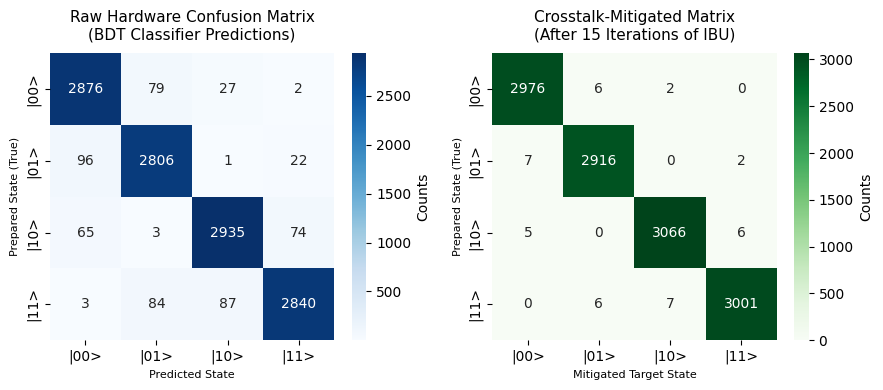

In [212]:
matrix_A_mitigated = []
for i in range(4):
    raw_hardware_counts = cm_bdt[i,:]
    matrix_A_mitigated.append(run_2qubit_ibu(raw_hardware_counts, matrix_A_crosstalk, max_iterations=15))

matrix_A_final = np.array(matrix_A_mitigated).round().astype(int)


import seaborn as sns

state_labels = ['|00>', '|01>', '|10>', '|11>']

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Raw Confusion Matrix
sns.heatmap(cm_bdt, annot=True, fmt='d', cmap='Blues', xticklabels=state_labels, yticklabels=state_labels, ax=axes[0],cbar_kws={'label': 'Counts'})
axes[0].set_title('Raw Hardware Confusion Matrix\n(BDT Classifier Predictions)', fontsize=11, pad=10)
axes[0].set_xlabel('Predicted State', fontsize=8)
axes[0].set_ylabel('Prepared State (True)', fontsize=8)

# Mitigated Matrix
sns.heatmap(matrix_A_final, annot=True, fmt='d', cmap='Greens', xticklabels=state_labels, yticklabels=state_labels, ax=axes[1],cbar_kws={'label': 'Counts'})
axes[1].set_title('Crosstalk-Mitigated Matrix\n(After 15 Iterations of IBU)', fontsize=11, pad=10)
axes[1].set_xlabel('Mitigated Target State', fontsize=8)
axes[1].set_ylabel('Prepared State (True)', fontsize=8)

plt.tight_layout()
plt.show()

# More on IQ:
Checked the following:

1. the $\phi$ distribution using I and Q for both qubits individually overlapped for the four various states
2. The amplitude distribution using I and Q for both qubits individually overlapped for the four quantum states and the gaussian fit

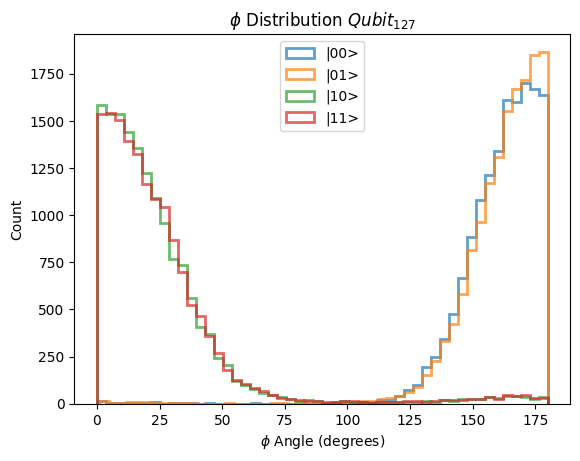

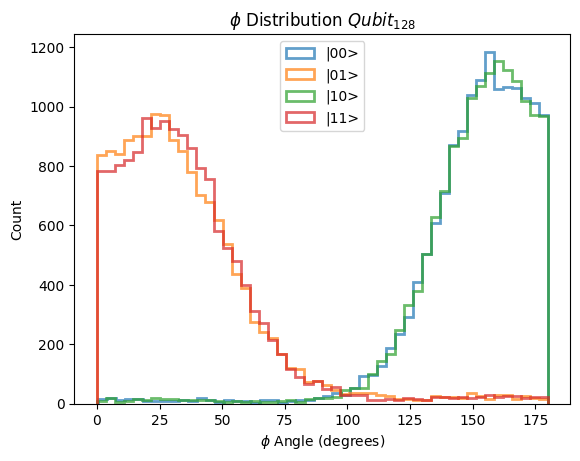

In [181]:
states = {0: '|00>', 1: '|01>', 2: '|10>', 3: '|11>',}
phi_q1 = {}
phi_q2 = {}

for n,x in enumerate([X00, X01, X10, X11]):
    phi_q1[n] = np.degrees(np.arctan2(x[:,1], x[:,0]))
    phi_q2[n] = np.degrees(np.arctan2(x[:,3], x[:,2]))


for i in range(4):
    plt.hist(abs(phi_q1[i]),bins=50, label = states[i], alpha=0.7, linewidth=2, histtype='step')

plt.title(f"$\phi$ Distribution $Qubit_{{{127}}}$")
plt.xlabel("$\phi$ Angle (degrees)")
plt.ylabel("Count")
plt.legend()
#plt.yscale('log')
plt.show()


for i in range(4):
    plt.hist(abs(phi_q2[i]),bins=50, label = states[i], alpha=0.7, linewidth=2, histtype='step')

plt.title(f"$\phi$ Distribution $Qubit_{{{128}}}$")
plt.xlabel("$\phi$ Angle (degrees)")
plt.ylabel("Count")
plt.legend()
#plt.yscale('log')
plt.show()


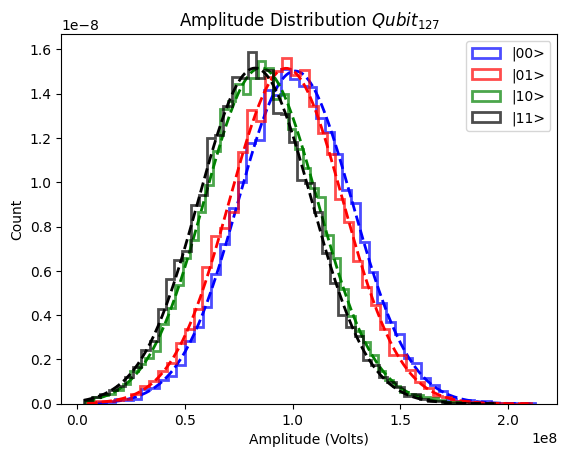

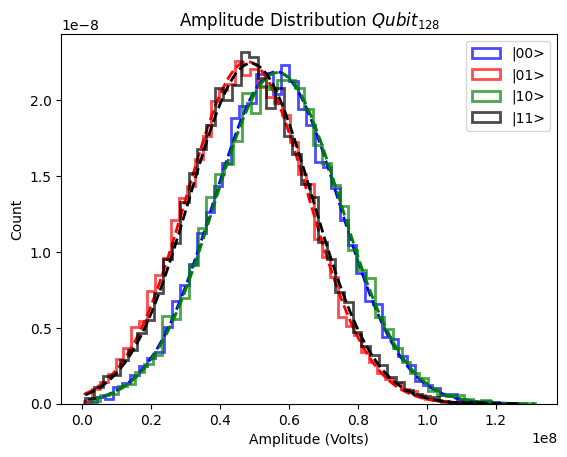

Qubit=127:  
    state: |00>, mu1 = 1.01e+08, std1 = 2.65e+07
    state: |01>, mu1 = 9.70e+07, std1 = 2.63e+07
    state: |10>, mu1 = 8.52e+07, std1 = 2.63e+07
    state: |11>, mu1 = 8.25e+07, std1 = 2.63e+07
Qubit=128:  
    state: |00>, mu2 = 5.63e+07, std2 = 1.82e+07
    state: |01>, mu2 = 4.79e+07, std2 = 1.77e+07
    state: |10>, mu2 = 5.67e+07, std2 = 1.83e+07
    state: |11>, mu2 = 4.89e+07, std2 = 1.78e+07


In [ ]:




R1, R2 = {}, {}
mu1, std1, mu2, std2 = {}, {}, {}, {}
x1, x2 = {}, {}
for n,x in enumerate([X00, X01, X10, X11]):
    R1[n] = np.sqrt(x[:,0]**2 + x[:,1]**2)
    R2[n] = np.sqrt(x[:,2]**2 + x[:,3]**2)
    mu1[n], std1[n] = norm.fit(R1[n])
    mu2[n], std2[n] = norm.fit(R2[n])
    x1[n] = np.linspace(min(R1[n]), max(R1[n]), 200)
    x2[n] = np.linspace(min(R2[n]), max(R2[n]), 200)

c = ['blue','red','green','black']

for i in range(4):
    plt.hist(R1[i], bins=50, label = states[i], alpha=0.7, linewidth=2, histtype='step',density=True,color=c[i])
    plt.plot(x1[i], norm.pdf(x1[i], mu1[i], std1[i]), linewidth=2,color=c[i],linestyle='dashed')
    
    
plt.title(f"Amplitude Distribution $Qubit_{{{127}}}$")
plt.xlabel("Amplitude (Volts)")
plt.ylabel("Count")
plt.legend()
plt.show()


for i in range(4):
    plt.hist(R2[i], bins=50, label = states[i], alpha=0.7, linewidth=2, histtype='step',density=True,color=c[i])  
    plt.plot(x2[i], norm.pdf(x2[i], mu2[i], std2[i]), linewidth=2, color=c[i],linestyle='dashed')
    
plt.title(f"Amplitude Distribution $Qubit_{{{128}}}$")
plt.xlabel("Amplitude (Volts)")
plt.ylabel("Count")
plt.legend()
plt.show()

print('Qubit=127:  ')
for i in range(4):
    print(f'    state: {states[i]}, mu1 = {mu1[i]:.2e}, std1 = {std1[i]:.2e}')

print('Qubit=128:  ')
for i in range(4):
    print(f'    state: {states[i]}, mu2 = {mu2[i]:.2e}, std2 = {std2[i]:.2e}')

# Using Builtin Readout Mitigation Methods

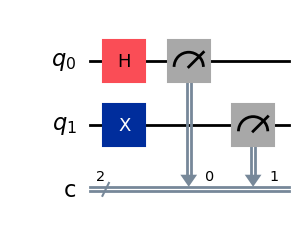

In [ ]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.x(1)
 
qc.measure(qc.qregs[0],qc.cregs[0])
qc.draw(output="mpl")


In [ ]:
backend = AerSimulator() # default qasm simulator

transpiled_circuit = transpile(qc, backend)
job = backend.run(transpiled_circuit, shots=1024)
results = job.result()
ideal_counts = results.get_counts()

In [ ]:


noise_model = NoiseModel()
initial_circuit_layout = [127, 128]

for qi in range(2):
    qno = initial_circuit_layout[qi]
    p0given1 = props.qubit_property(qno, 'prob_meas0_prep1')[0]
    p1given0 = props.qubit_property(qno, 'prob_meas1_prep0')[0]
    read_err = ReadoutError([[1 - p1given0, p1given0], [p0given1, 1 - p0given1]])
    noise_model.add_readout_error(read_err, [qno])

In [278]:
transpiled_circuit = transpile(qc, backend=backend, optimization_level=3,  initial_layout=[127, 128], translation_method="translator")
sim_bck_noise = AerSimulator()
job_noise = sim_bck_noise.run(transpiled_circuit, noise_model=noise_model, shots=1024)

result_noise = job_noise.result()
noisy_counts = result_noise.get_counts()

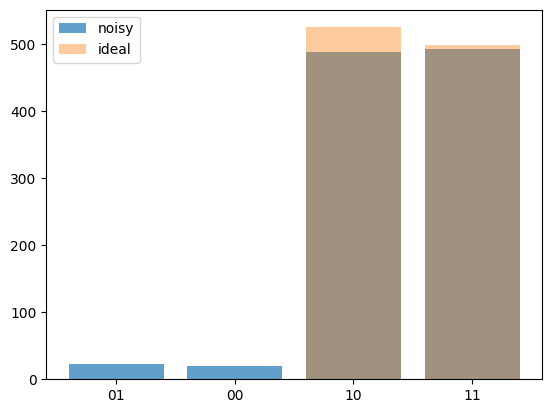

In [279]:
plt.bar(noisy_counts.keys(), noisy_counts.values(),label='noisy', alpha=0.7)
plt.bar(ideal_counts.keys(), ideal_counts.values(),label='ideal', alpha=0.4)
plt.legend()

In [ ]:


def complete_meas_cal_clean(qubits, circlabel='mcal'):
    n = len(qubits)
    circuits = []
    state_labels = [format(i, f'0{n}b') for i in range(2**n)]
    for label in state_labels:
        qc = QuantumCircuit(n, n, name=f"{circlabel}_{label}")
        for idx, bit in enumerate(reversed(label)):
            if bit == '1':
                qc.x(idx)                
        qc.measure(range(n), range(n))
        circuits.append(qc)
    return circuits, state_labels

meas_calibs, state_labels = complete_meas_cal_clean([127, 128], circlabel='mcal')

In [288]:
sim_backend = AerSimulator.from_backend(backend)
transpiled_calibs = transpile(meas_calibs, backend=sim_backend, initial_layout=[127, 128])

job = sim_backend.run(transpiled_calibs, shots=1024, noise_model=noise_model)
cal_results = job.result()

def get_calibration_matrix(results, state_labels, circlabel='mcal'):
    n = len(state_labels)
    matrix = np.zeros((n, n))    
    for j, prep_state in enumerate(state_labels):
        circuit_name = f"{circlabel}_{prep_state}"
        counts = results.get_counts(circuit_name)
        total_shots = sum(counts.values())
        
        for i, meas_state in enumerate(state_labels):
            matrix[i, j] = counts.get(meas_state, 0) / total_shots            
    return matrix

cal_matrix = get_calibration_matrix(cal_results, state_labels, circlabel='mcal')
print(cal_matrix)

[[0.90527344 0.08789062 0.04394531 0.00390625]
 [0.06933594 0.89257812 0.00390625 0.02929688]
 [0.0234375  0.00097656 0.87402344 0.08496094]
 [0.00195312 0.01855469 0.078125   0.88183594]]


In [290]:
transpiled_qc = transpile(qc, backend=sim_backend, initial_layout=[127, 128])

job = sim_backend.run(transpiled_qc, shots=1024, noise_model=noise_model)
raw_results = job.result()
raw_counts = raw_results.get_counts()

def apply_measurement_mitigation(raw_counts, cal_matrix, state_labels):
    n = len(state_labels)
    
    total_shots = sum(raw_counts.values())
    raw_vector = np.array([raw_counts.get(state, 0) for state in state_labels])
    
    inv_cal_matrix = np.linalg.pinv(cal_matrix)
    mitigated_vector = inv_cal_matrix @ raw_vector
    mitigated_vector = np.clip(mitigated_vector, 0, None)
    if np.sum(mitigated_vector) > 0:
        mitigated_vector = (mitigated_vector / np.sum(mitigated_vector)) * total_shots
    mitigated_counts = {
        state: int(np.round(count)) 
        for state, count in zip(state_labels, mitigated_vector) if np.round(count) > 0
    }    
    return mitigated_counts


mitigated_counts = apply_measurement_mitigation(raw_counts, cal_matrix, state_labels)

print("Raw Counts:      ", raw_counts)
print("Mitigated Counts:", mitigated_counts)

Raw Counts:       {'01': 23, '00': 22, '11': 490, '10': 489}
Mitigated Counts: {'01': 7, '10': 508, '11': 509}


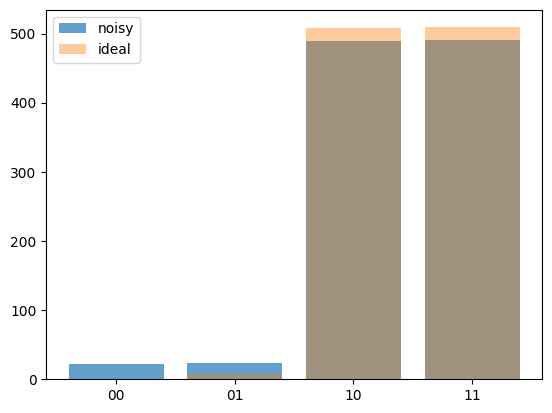

In [294]:
raw_counts_cor = {}
mitigated_counts_cor = {}
mitigated_counts['00'] = 0
for i in sorted(raw_counts.keys()):
    raw_counts_cor[i] = raw_counts[i]
    mitigated_counts_cor[i] = mitigated_counts[i]

plt.bar(sorted(raw_counts_cor.keys()), raw_counts_cor.values(),label='noisy', alpha=0.7)
plt.bar(mitigated_counts_cor.keys(), mitigated_counts_cor.values(),label='ideal', alpha=0.4)
plt.legend()